In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [2]:
# Load Breast Cancer binary classification dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)
print("Unique labels:", np.unique(y))

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Unique labels: [0 1]


In [3]:
# Convert dataset into a DataFrame
df = pd.DataFrame(X, columns=data.feature_names)

# Add target column
df["target"] = y

print(df.head())
print("\nDataset shape:", df.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

target
1    357
0    212
Name: count, dtype: int64


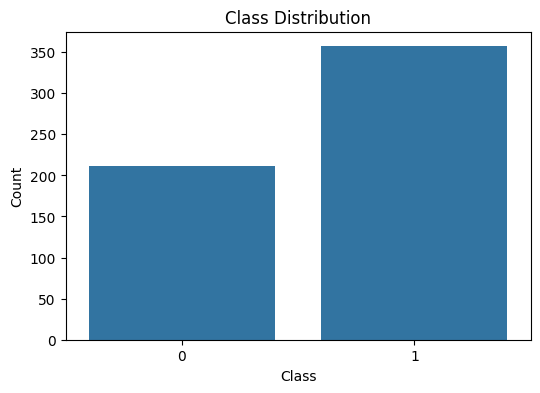

In [4]:
# Check the number of samples in each class
print(df["target"].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["target"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [5]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [6]:
# StandardScaler is important for Logistic Regression
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [7]:
# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Generate predictions
logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [8]:
# Print classification report
print("Logistic Regression Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    logistic_pred,
    target_names=data.target_names
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



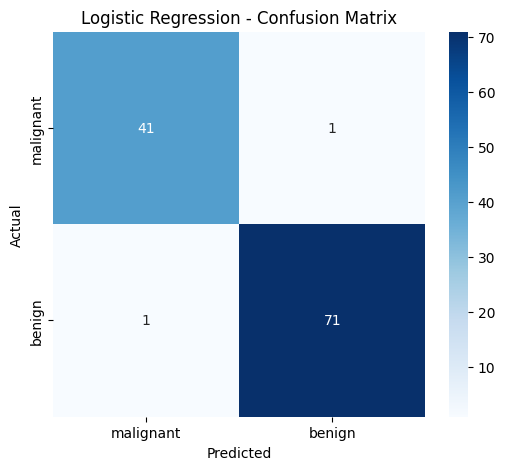

In [9]:
# Calculate confusion matrix
cm_logistic = confusion_matrix(y_test, logistic_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

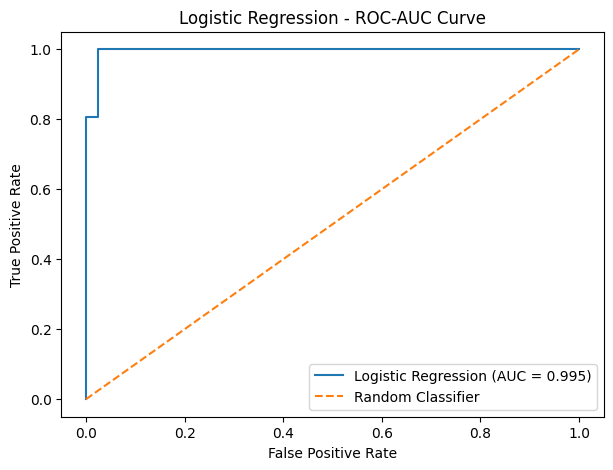

Logistic Regression ROC-AUC: 0.9954


In [10]:
# Get prediction probabilities
logistic_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC
logistic_auc = roc_auc_score(
    y_test,
    logistic_probability
)

# Calculate ROC curve
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probability
)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC-AUC Curve")
plt.legend()
plt.show()

print("Logistic Regression ROC-AUC:", round(logistic_auc, 4))

In [11]:
# Create Random Forest classifier
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Random Forest
random_forest.fit(X_train, y_train)

# Generate predictions
rf_pred = random_forest.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [12]:
# Print Random Forest classification report
print("Random Forest Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    rf_pred,
    target_names=data.target_names
))

# Calculate Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))

Random Forest Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722


In [13]:
# Calculate Logistic Regression metrics
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)

# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "ROC-AUC": [
        logistic_auc,
        roc_auc_score(
            y_test,
            random_forest.predict_proba(X_test)[:, 1]
        )
    ]
})

print(comparison.round(4))

                 Model  Accuracy  Precision  Recall  ROC-AUC
0  Logistic Regression    0.9825     0.9861  0.9861   0.9954
1        Random Forest    0.9561     0.9589  0.9722   0.9937


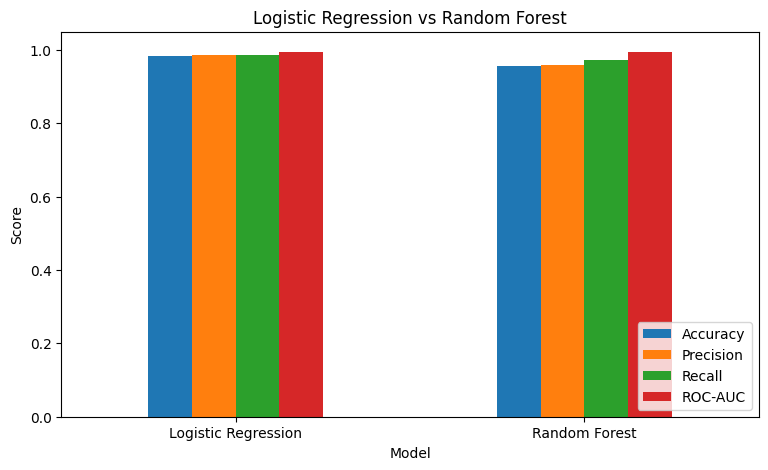

In [14]:
# Plot model comparison
comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()